In [461]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [462]:
data = {
    "Age":[45,50,42,48,52,46,44,49,51],
    "Gender":["M","F","M","F","M","F","M","F","M"],
    "Treatment":["A","A","A","B","B","B","C","C","C"],
    "BP_Before":[150,160,145,155,165,150,158,162,170],
    "BP_After":[135,140,130,125,130,120,118,122,125],
    "PainScore":[3,2,4,1,2,1,1,2,1],
    "RecoveryDays":[10,12,9,7,8,6,5,6,5],
    "Recovered":["No","No","No","Yes","No","Yes","Yes","Yes","Yes"]
}

df = pd.DataFrame(data)

# Create BP Reduction Column
df["BP_Reduction"] = df["BP_Before"] - df["BP_After"]

In [463]:
df

,Age,Gender,Treatment,BP_Before,BP_After,PainScore,RecoveryDays,Recovered,BP_Reduction
0,45,M,A,150,135,3,10,No,15
1,50,F,A,160,140,2,12,No,20
2,42,M,A,145,130,4,9,No,15
3,48,F,B,155,125,1,7,Yes,30
4,52,M,B,165,130,2,8,No,35
5,46,F,B,150,120,1,6,Yes,30
6,44,M,C,158,118,1,5,Yes,40
7,49,F,C,162,122,2,6,Yes,40
8,51,M,C,170,125,1,5,Yes,45


In [464]:
df.head()

,Age,Gender,Treatment,BP_Before,BP_After,PainScore,RecoveryDays,Recovered,BP_Reduction
0,45,M,A,150,135,3,10,No,15
1,50,F,A,160,140,2,12,No,20
2,42,M,A,145,130,4,9,No,15
3,48,F,B,155,125,1,7,Yes,30
4,52,M,B,165,130,2,8,No,35


In [465]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Age           9 non-null      int64 
 1   Gender        9 non-null      object
 2   Treatment     9 non-null      object
 3   BP_Before     9 non-null      int64 
 4   BP_After      9 non-null      int64 
 5   PainScore     9 non-null      int64 
 6   RecoveryDays  9 non-null      int64 
 7   Recovered     9 non-null      object
 8   BP_Reduction  9 non-null      int64 
dtypes: int64(6), object(3)
memory usage: 780.0+ bytes


In [466]:
df.shape

(9, 9)

In [467]:
df.columns

Index(['Age', 'Gender', 'Treatment', 'BP_Before', 'BP_After', 'PainScore',
       'RecoveryDays', 'Recovered', 'BP_Reduction'],
      dtype='object')

In [468]:
df.dtypes

,0
Age,int64
Gender,object
Treatment,object
BP_Before,int64
BP_After,int64
PainScore,int64
RecoveryDays,int64
Recovered,object
BP_Reduction,int64


In [469]:
df.describe()

,Age,BP_Before,BP_After,PainScore,RecoveryDays,BP_Reduction
count,9.000000,9.000000,9.000000,9.000000,9.000000,9.00000
mean,47.444444,157.222222,127.222222,1.888889,7.555556,30.00000
std,3.395258,8.012144,7.189885,1.054093,2.403701,11.18034
min,42.000000,145.000000,118.000000,1.000000,5.000000,15.00000
25%,45.000000,150.000000,122.000000,1.000000,6.000000,20.00000
50%,48.000000,158.000000,125.000000,2.000000,7.000000,30.00000
75%,50.000000,162.000000,130.000000,2.000000,9.000000,40.00000
max,52.000000,170.000000,140.000000,4.000000,12.000000,45.00000


In [470]:
df.describe(include='number')

,Age,BP_Before,BP_After,PainScore,RecoveryDays,BP_Reduction
count,9.000000,9.000000,9.000000,9.000000,9.000000,9.00000
mean,47.444444,157.222222,127.222222,1.888889,7.555556,30.00000
std,3.395258,8.012144,7.189885,1.054093,2.403701,11.18034
min,42.000000,145.000000,118.000000,1.000000,5.000000,15.00000
25%,45.000000,150.000000,122.000000,1.000000,6.000000,20.00000
50%,48.000000,158.000000,125.000000,2.000000,7.000000,30.00000
75%,50.000000,162.000000,130.000000,2.000000,9.000000,40.00000
max,52.000000,170.000000,140.000000,4.000000,12.000000,45.00000


## Key Insights
Average BP before treatment = 157

Average BP after treatment = 127

Average BP reduction = 30 points

Average recovery time = 7.56 days

In [471]:
df.describe(include='object')

,Gender,Treatment,Recovered
count,9,9,9
unique,2,3,2
top,M,A,Yes
freq,5,3,5


In [472]:
df.isna().sum()

,0
Age,0
Gender,0
Treatment,0
BP_Before,0
BP_After,0
PainScore,0
RecoveryDays,0
Recovered,0
BP_Reduction,0


## Insight:
Dataset is completely clean.

In [473]:
df.duplicated().sum()

np.int64(0)

In [474]:
num_col = df.select_dtypes(include='number')
num_col

,Age,BP_Before,BP_After,PainScore,RecoveryDays,BP_Reduction
0,45,150,135,3,10,15
1,50,160,140,2,12,20
2,42,145,130,4,9,15
3,48,155,125,1,7,30
4,52,165,130,2,8,35
5,46,150,120,1,6,30
6,44,158,118,1,5,40
7,49,162,122,2,6,40
8,51,170,125,1,5,45


In [475]:
cat_col = df.select_dtypes(include='object')
cat_col

,Gender,Treatment,Recovered
0,M,A,No
1,F,A,No
2,M,A,No
3,F,B,Yes
4,M,B,No
5,F,B,Yes
6,M,C,Yes
7,F,C,Yes
8,M,C,Yes


In [476]:
df.describe(include= 'all')

,Age,Gender,Treatment,BP_Before,BP_After,PainScore,RecoveryDays,Recovered,BP_Reduction
count,9.000000,9,9,9.000000,9.000000,9.000000,9.000000,9,9.00000
unique,NaN,2,3,NaN,NaN,NaN,NaN,2,NaN
top,NaN,M,A,NaN,NaN,NaN,NaN,Yes,NaN
freq,NaN,5,3,NaN,NaN,NaN,NaN,5,NaN
mean,47.444444,NaN,NaN,157.222222,127.222222,1.888889,7.555556,NaN,30.00000
std,3.395258,NaN,NaN,8.012144,7.189885,1.054093,2.403701,NaN,11.18034
min,42.000000,NaN,NaN,145.000000,118.000000,1.000000,5.000000,NaN,15.00000
25%,45.000000,NaN,NaN,150.000000,122.000000,1.000000,6.000000,NaN,20.00000
50%,48.000000,NaN,NaN,158.000000,125.000000,2.000000,7.000000,NaN,30.00000
75%,50.000000,NaN,NaN,162.000000,130.000000,2.000000,9.000000,NaN,40.00000


In [477]:
num_col.columns

Index(['Age', 'BP_Before', 'BP_After', 'PainScore', 'RecoveryDays',
       'BP_Reduction'],
      dtype='object')

In [478]:
cat_col.columns

Index(['Gender', 'Treatment', 'Recovered'], dtype='object')

In [479]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,9.0,47.444444,3.395258,42.0,45.0,48.0,50.0,52.0
BP_Before,9.0,157.222222,8.012144,145.0,150.0,158.0,162.0,170.0
BP_After,9.0,127.222222,7.189885,118.0,122.0,125.0,130.0,140.0
PainScore,9.0,1.888889,1.054093,1.0,1.0,2.0,2.0,4.0
RecoveryDays,9.0,7.555556,2.403701,5.0,6.0,7.0,9.0,12.0
BP_Reduction,9.0,30.000000,11.180340,15.0,20.0,30.0,40.0,45.0


In [480]:
df

,Age,Gender,Treatment,BP_Before,BP_After,PainScore,RecoveryDays,Recovered,BP_Reduction
0,45,M,A,150,135,3,10,No,15
1,50,F,A,160,140,2,12,No,20
2,42,M,A,145,130,4,9,No,15
3,48,F,B,155,125,1,7,Yes,30
4,52,M,B,165,130,2,8,No,35
5,46,F,B,150,120,1,6,Yes,30
6,44,M,C,158,118,1,5,Yes,40
7,49,F,C,162,122,2,6,Yes,40
8,51,M,C,170,125,1,5,Yes,45


In [481]:
for col in df.columns:
    print(col, df[col].unique())

Age [45 50 42 48 52 46 44 49 51]
Gender ['M' 'F']
Treatment ['A' 'B' 'C']
BP_Before [150 160 145 155 165 158 162 170]
BP_After [135 140 130 125 120 118 122]
PainScore [3 2 4 1]
RecoveryDays [10 12  9  7  8  6  5]
Recovered ['No' 'Yes']
BP_Reduction [15 20 30 35 40 45]


In [482]:
df

,Age,Gender,Treatment,BP_Before,BP_After,PainScore,RecoveryDays,Recovered,BP_Reduction
0,45,M,A,150,135,3,10,No,15
1,50,F,A,160,140,2,12,No,20
2,42,M,A,145,130,4,9,No,15
3,48,F,B,155,125,1,7,Yes,30
4,52,M,B,165,130,2,8,No,35
5,46,F,B,150,120,1,6,Yes,30
6,44,M,C,158,118,1,5,Yes,40
7,49,F,C,162,122,2,6,Yes,40
8,51,M,C,170,125,1,5,Yes,45


# Recovery Distribution

In [483]:
# Recovery Distribution
recovery_counts = df['Recovered'].value_counts()

In [484]:
print("Recovery Distribution:")
print(recovery_counts)

Recovery Distribution:
Recovered
Yes    5
No     4
Name: count, dtype: int64


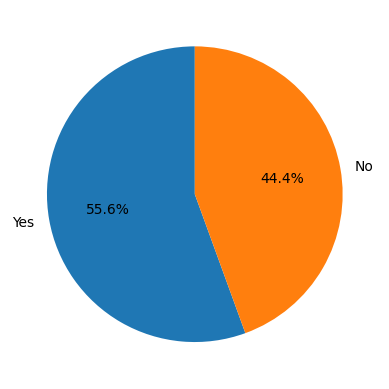

In [485]:
plt.pie(
    recovery_counts,
    labels=recovery_counts.index,
    autopct='%1.1f%%',
    startangle=90,
)
plt.show()

# Treatment-wise Recovery Analysis

In [486]:
# Treatment-wise Recovery Analysis
treatment_recovery = df.groupby('Treatment')['Recovered'].apply(
    lambda x: (x == 'Yes').sum()
).reset_index(name='Recovered')

In [487]:
print(treatment_recovery)

  Treatment  Recovered
0         A          0
1         B          2
2         C          3


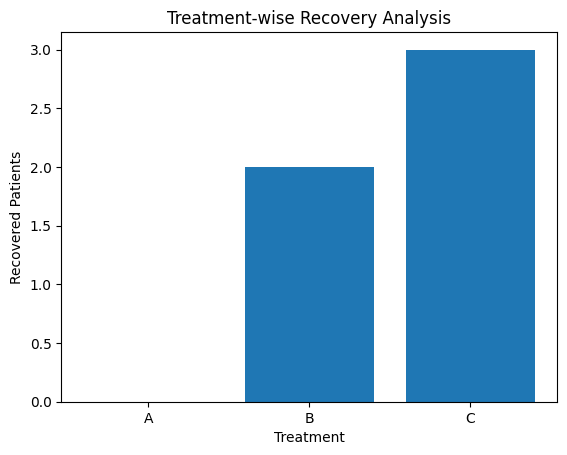

In [488]:
# Bar Chart
plt.bar(
    treatment_recovery['Treatment'],
    treatment_recovery['Recovered']
)

plt.title('Treatment-wise Recovery Analysis')
plt.xlabel('Treatment')
plt.ylabel('Recovered Patients')
plt.show()


# Insight

Treatment C achieved 100% recovery (3/3 patients).

Treatment B achieved 66.67% recovery (2/3 patients).

Treatment A achieved 0% recovery (0/3 patients).

# Average BP Reduction by Treatment

In [489]:
avg_bp = df.groupby('Treatment')['BP_Reduction'].mean().reset_index()

print("Average BP Reduction by Treatment")
print(avg_bp)

Average BP Reduction by Treatment
  Treatment  BP_Reduction
0         A     16.666667
1         B     31.666667
2         C     41.666667


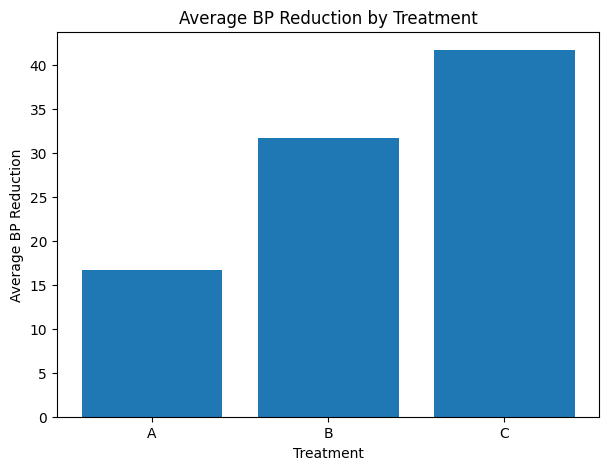

In [490]:
# Bar Chart
plt.figure(figsize=(7,5))
bars = plt.bar(
    avg_bp['Treatment'],
    avg_bp['BP_Reduction']
)

plt.title('Average BP Reduction by Treatment')
plt.xlabel('Treatment')
plt.ylabel('Average BP Reduction')
plt.show()

# Average BP Reduction by Treatment

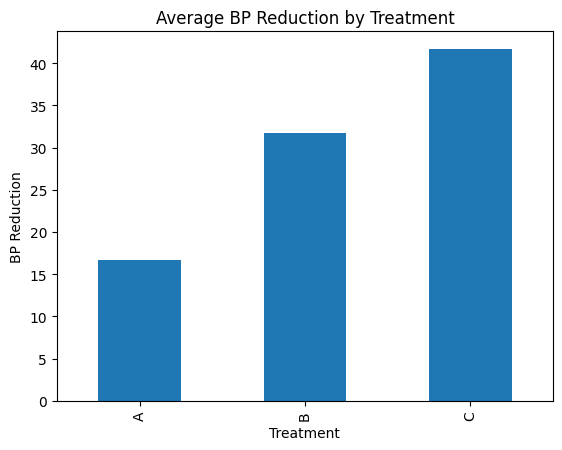


Average BP Reduction
Treatment
A    16.666667
B    31.666667
C    41.666667
Name: BP_Reduction, dtype: float64


In [491]:
bp_reduction = df.groupby("Treatment")["BP_Reduction"].mean()

bp_reduction.plot(kind='bar')
plt.title("Average BP Reduction by Treatment")
plt.ylabel("BP Reduction")
plt.show()

print("\nAverage BP Reduction")
print(bp_reduction)

# Insight

Treatment C provides the largest BP reduction.

# Recovery Days Per Patient




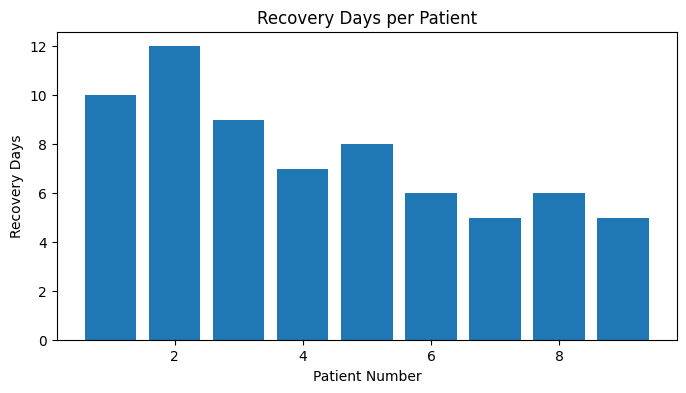

In [492]:
plt.figure(figsize=(8,4))
plt.bar(range(1,10), df["RecoveryDays"])
plt.xlabel("Patient Number")
plt.ylabel("Recovery Days")
plt.title("Recovery Days per Patient")
plt.show()

# Insight

Patients receiving Treatment C recovered fastest (5–6 days).

# Age vs BP Reduction

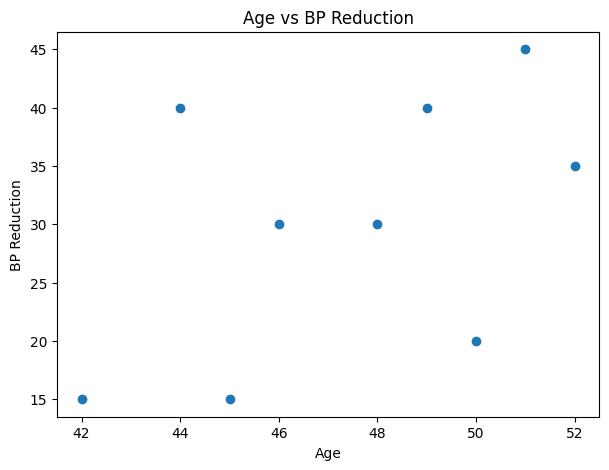

In [493]:
plt.figure(figsize=(7,5))
plt.scatter(df["Age"], df["BP_Reduction"])
plt.xlabel("Age")
plt.ylabel("BP Reduction")
plt.title("Age vs BP Reduction")
plt.show()

# Pain Score Distribution

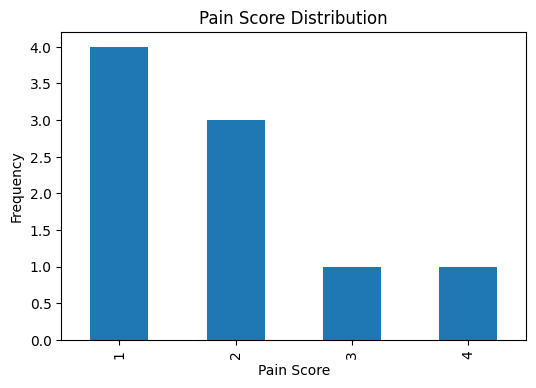

In [494]:
pain_counts = df["PainScore"].value_counts().sort_index()

plt.figure(figsize=(6,4))
pain_counts.plot(kind='bar')
plt.title("Pain Score Distribution")
plt.xlabel("Pain Score")
plt.ylabel("Frequency")
plt.show()

#  BP Before vs BP After

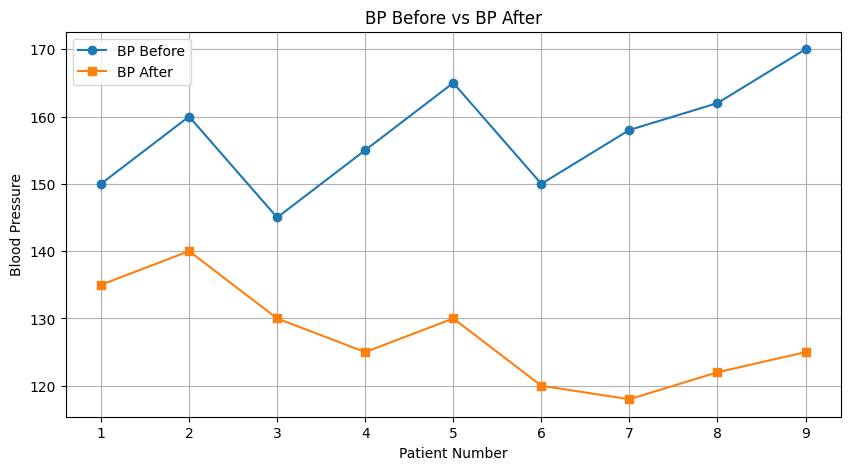

In [495]:


plt.figure(figsize=(10,5))

plt.plot(
    range(1,10),
    df["BP_Before"],
    marker='o',
    label='BP Before'
)

plt.plot(
    range(1,10),
    df["BP_After"],
    marker='s',
    label='BP After'
)

plt.xlabel("Patient Number")
plt.ylabel("Blood Pressure")
plt.title("BP Before vs BP After")
plt.legend()
plt.grid(True)
plt.show()

In [496]:
df

,Age,Gender,Treatment,BP_Before,BP_After,PainScore,RecoveryDays,Recovered,BP_Reduction
0,45,M,A,150,135,3,10,No,15
1,50,F,A,160,140,2,12,No,20
2,42,M,A,145,130,4,9,No,15
3,48,F,B,155,125,1,7,Yes,30
4,52,M,B,165,130,2,8,No,35
5,46,F,B,150,120,1,6,Yes,30
6,44,M,C,158,118,1,5,Yes,40
7,49,F,C,162,122,2,6,Yes,40
8,51,M,C,170,125,1,5,Yes,45


# Paired T-Test

In [497]:
from scipy.stats import ttest_rel

t_stat, p_value = ttest_rel(
    df["BP_Before"],
    df["BP_After"]
)

print("Paired T-Test")
print("T-statistic:", t_stat)
print("P-value:", p_value)

Paired T-Test
T-statistic: 8.049844718999243
P-value: 4.1757661627665775e-05


In [498]:
from scipy.stats import (
    ttest_rel,
    ttest_ind,
    f_oneway,
    chi2_contingency
)

from statsmodels.stats.proportion import proportions_ztest

# 1 Paired T Test
print("\nPAIRED T TEST")
print(ttest_rel(
    df["BP_Before"],
    df["BP_After"]
))

# 2 Independent T Test
male = df[df["Gender"]=="M"]["RecoveryDays"]
female = df[df["Gender"]=="F"]["RecoveryDays"]

print("\nINDEPENDENT T TEST")
print(ttest_ind(male,female))

# 3 ANOVA
A = df[df["Treatment"]=="A"]["BP_Reduction"]
B = df[df["Treatment"]=="B"]["BP_Reduction"]
C = df[df["Treatment"]=="C"]["BP_Reduction"]

print("\nANOVA")
print(f_oneway(A,B,C))

# 4 Chi Square
table = pd.crosstab(
    df["Treatment"],
    df["Recovered"]
)

print("\nCHI SQUARE")
print(chi2_contingency(table))

# 5 Z TESTS

print("\nB vs C")
print(proportions_ztest(
    [2,3],
    [3,3]
))

print("\nA vs B")
print(proportions_ztest(
    [0,2],
    [3,3]
))

print("\nA vs C")
print(proportions_ztest(
    [0,3],
    [3,3]
))


PAIRED T TEST
TtestResult(statistic=np.float64(8.049844718999243), pvalue=np.float64(4.1757661627665775e-05), df=np.int64(8))

INDEPENDENT T TEST
TtestResult(statistic=np.float64(-0.2036423263325046), pvalue=np.float64(0.8444265617391499), df=np.float64(7.0))

ANOVA
F_onewayResult(statistic=np.float64(56.99999999999999), pvalue=np.float64(0.00012500000000000003))

CHI SQUARE
Chi2ContingencyResult(statistic=np.float64(6.300000000000001), pvalue=np.float64(0.04285212686704016), dof=2, expected_freq=array([[1.33333333, 1.66666667],
       [1.33333333, 1.66666667],
       [1.33333333, 1.66666667]]))

B vs C
(np.float64(-1.0954451150103326), np.float64(0.2733216782922979))

A vs B
(np.float64(-1.7320508075688772), np.float64(0.0832645166635504))

A vs C
(np.float64(-2.449489742783178), np.float64(0.014305878435429648))


In [499]:
from sklearn.preprocessing import LabelEncoder

In [500]:
le = LabelEncoder()

In [501]:
df["Gender"] = le.fit_transform(df["Gender"])
df["Treatment"] = le.fit_transform(df["Treatment"])
df["Recovered"] = le.fit_transform(df["Recovered"])

df

,Age,Gender,Treatment,BP_Before,BP_After,PainScore,RecoveryDays,Recovered,BP_Reduction
0,45,1,0,150,135,3,10,0,15
1,50,0,0,160,140,2,12,0,20
2,42,1,0,145,130,4,9,0,15
3,48,0,1,155,125,1,7,1,30
4,52,1,1,165,130,2,8,0,35
5,46,0,1,150,120,1,6,1,30
6,44,1,2,158,118,1,5,1,40
7,49,0,2,162,122,2,6,1,40
8,51,1,2,170,125,1,5,1,45


# Classification Models
## Target = Recovered

In [502]:
from sklearn.model_selection import train_test_split

X = df.drop("Recovered", axis=1)
y = df["Recovered"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.3,
    random_state=42
)

In [503]:
X

,Age,Gender,Treatment,BP_Before,BP_After,PainScore,RecoveryDays,BP_Reduction
0,45,1,0,150,135,3,10,15
1,50,0,0,160,140,2,12,20
2,42,1,0,145,130,4,9,15
3,48,0,1,155,125,1,7,30
4,52,1,1,165,130,2,8,35
5,46,0,1,150,120,1,6,30
6,44,1,2,158,118,1,5,40
7,49,0,2,162,122,2,6,40
8,51,1,2,170,125,1,5,45


In [504]:
y

,Recovered
0,0
1,0
2,0
3,1
4,0
5,1
6,1
7,1
8,1


# 1. Logistic Regression

In [505]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression()

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test,pred))

Accuracy: 1.0


# 2. Decision Tree

In [506]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test,pred))

Accuracy: 1.0


# 3. Random Forest

In [507]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100
)

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test,pred))

Accuracy: 1.0


# 4. KNN

In [508]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(
    n_neighbors=3
)

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test,pred))

Accuracy: 1.0


# 5. Naive Bayes

In [509]:
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test,pred))

Accuracy: 1.0


# Regression Models
## Predict BP Reduction

In [510]:
X = df.drop("BP_Reduction",axis=1)
y = df["BP_Reduction"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.3,
    random_state=42
)

# 6. Linear Regression

In [511]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test, pred)

print("RMSE:", rmse)

RMSE: 30.342489460600735


In [512]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Make predictions
pred = model.predict(X_test)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("RMSE:", rmse)

RMSE: 0.20357743746372484


# 7. Decision Tree Regressor

In [513]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predictions
pred = model.predict(X_test)

# Calculate RMSE
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 0.20357743746372484


# 9. Random Forest Regressor

In [514]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# Create model
model = RandomForestRegressor(random_state=42)

# Train model
model.fit(X_train, y_train)

# Predictions
pred = model.predict(X_test)

# Calculate RMSE
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)

print("RMSE:", rmse)

RMSE: 3.0371313219330287


# Clustering
## K-Means

In [515]:
from sklearn.cluster import KMeans

X = df[[
    "Age",
    "BP_Before",
    "BP_After",
    "BP_Reduction"
]]

kmeans = KMeans(n_clusters=3,random_state=42)

df["Cluster"] = kmeans.fit_predict(X)

print(df[[
    "Age",
    "BP_Reduction",
    "Cluster"
]])

   Age  BP_Reduction  Cluster
0   45            15        2
1   50            20        2
2   42            15        2
3   48            30        0
4   52            35        1
5   46            30        0
6   44            40        1
7   49            40        1
8   51            45        1


# Hierarchical Clustering

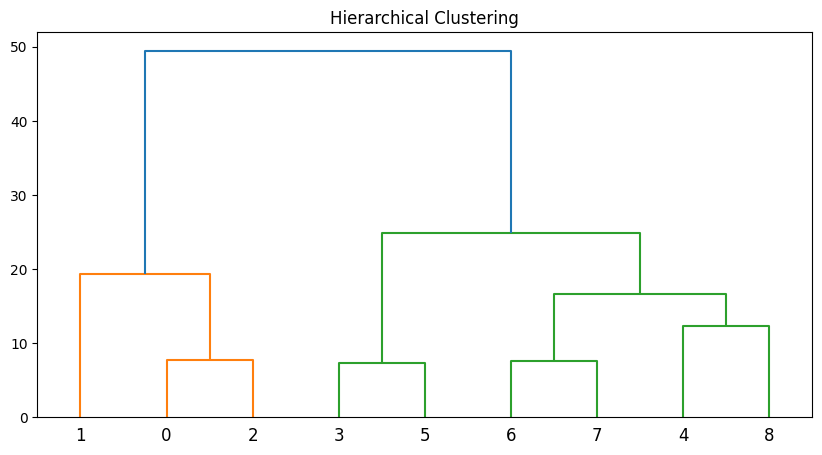

In [516]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X,method='ward')

plt.figure(figsize=(10,5))

dendrogram(Z)

plt.title("Hierarchical Clustering")

plt.show()

# PCA
## Dimensionality Reduction

In [517]:
from sklearn.decomposition import PCA

X = df.drop(
    "Recovered",
    axis=1
)

pca = PCA(
    n_components=2
)

X_pca = pca.fit_transform(X)

print(X_pca)

[[-18.67192149   1.81153423]
 [-11.38650101  12.97937143]
 [-19.57269531  -5.85379989]
 [ -0.02947353  -2.88226798]
 [  7.12114454   7.86566893]
 [ -0.74392426 -10.23569113]
 [ 11.44898527  -8.27091091]
 [ 12.38083646  -1.24498476]
 [ 19.45354934   5.83108008]]


In [518]:
print(
    pca.explained_variance_ratio_
)

[0.75468813 0.23228975]


In [519]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(
    X_train,
    y_train
)

importance = pd.DataFrame({
    "Feature":X_train.columns,
    "Importance":model.feature_importances_
})

print(
    importance.sort_values(
        "Importance",
        ascending=False
    )
)

        Feature  Importance
0           Age    0.197884
3     BP_Before    0.182351
6  RecoveryDays    0.145449
2     Treatment    0.130169
4      BP_After    0.116896
5     PainScore    0.082930
7     Recovered    0.075147
1        Gender    0.069174


# DBSCAN (Density-Based Spatial Clustering)

In [520]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Features
X = df[[
    "Age",
    "BP_Before",
    "BP_After",
    "BP_Reduction",
    "RecoveryDays"
]]

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# DBSCAN
dbscan = DBSCAN(
    eps=1.5,
    min_samples=2
)

clusters = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = clusters

print(df[[
    "Age",
    "BP_Reduction",
    "DBSCAN_Cluster"
]])

   Age  BP_Reduction  DBSCAN_Cluster
0   45            15               0
1   50            20              -1
2   42            15               0
3   48            30               1
4   52            35              -1
5   46            30               1
6   44            40              -1
7   49            40               1
8   51            45               1


# Visualize DBSCAN

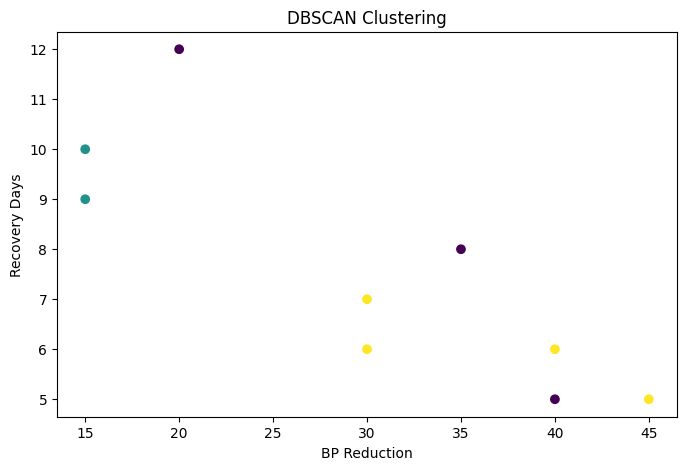

In [521]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    df["BP_Reduction"],
    df["RecoveryDays"],
    c=df["DBSCAN_Cluster"]
)

plt.xlabel("BP Reduction")
plt.ylabel("Recovery Days")
plt.title("DBSCAN Clustering")

plt.show()



# Agglomerative Clustering

In [522]:
from sklearn.cluster import AgglomerativeClustering

X = df[[
    "Age",
    "BP_Before",
    "BP_After",
    "BP_Reduction",
    "RecoveryDays"
]]

agg = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

clusters = agg.fit_predict(X)

df["Agglomerative_Cluster"] = clusters

print(df[[
    "Age",
    "BP_Reduction",
    "Agglomerative_Cluster"
]])

   Age  BP_Reduction  Agglomerative_Cluster
0   45            15                      0
1   50            20                      0
2   42            15                      0
3   48            30                      2
4   52            35                      1
5   46            30                      2
6   44            40                      1
7   49            40                      1
8   51            45                      1


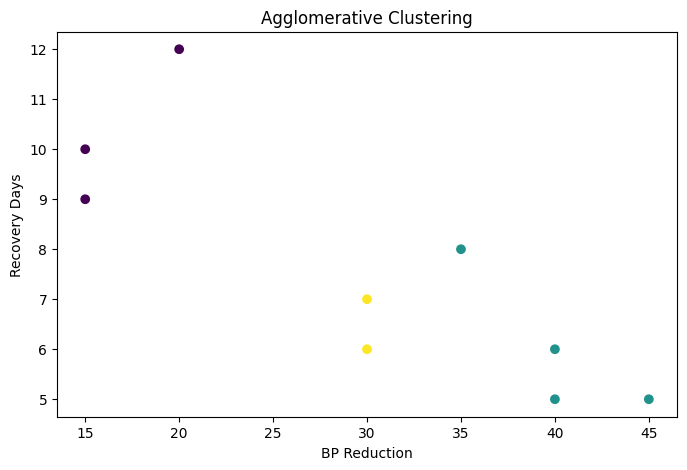

In [523]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["BP_Reduction"],
    df["RecoveryDays"],
    c=df["Agglomerative_Cluster"]
)

plt.xlabel("BP Reduction")
plt.ylabel("Recovery Days")

plt.title("Agglomerative Clustering")

plt.show()

In [524]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Encode categorical columns
df_ml = df.copy()

le = LabelEncoder()

df_ml["Gender"] = le.fit_transform(df_ml["Gender"])
df_ml["Treatment"] = le.fit_transform(df_ml["Treatment"])
df_ml["Recovered"] = le.fit_transform(df_ml["Recovered"])

X = df_ml.drop("Recovered", axis=1)
y = df_ml["Recovered"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

# Compare Classification Algorithms

In [525]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score
import pandas as pd

models = {

    "Logistic Regression":
        LogisticRegression(),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "KNN":
        KNeighborsClassifier(n_neighbors=3),

    "SVM":
        SVC(),

    "Naive Bayes":
        GaussianNB()
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    results.append([name, round(acc,4)])

results_df = pd.DataFrame(
    results,
    columns=["Algorithm","Accuracy"]
)

print(results_df.sort_values(
    by="Accuracy",
    ascending=False
))

             Algorithm  Accuracy
0  Logistic Regression       1.0
1        Decision Tree       1.0
2        Random Forest       1.0
3                  KNN       1.0
4                  SVM       1.0
5          Naive Bayes       1.0


# Compare Regression Algorithms

Target = BP Reduction

In [526]:
from sklearn.model_selection import train_test_split

X = df_ml.drop("BP_Reduction", axis=1)

y = df_ml["BP_Reduction"]

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

Regression Comparison

In [527]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np

models = {

    "Linear Regression":
        LinearRegression(),

    "Decision Tree":
        DecisionTreeRegressor(random_state=42),

    "Random Forest":
        RandomForestRegressor(random_state=42)
}

results = []

for name, model in models.items():

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )

    results.append(
        [name, round(rmse,2)]
    )

results_df = pd.DataFrame(
    results,
    columns=["Algorithm","RMSE"]
)

print(results_df.sort_values(
    by="RMSE"
))

           Algorithm   RMSE
0  Linear Regression   0.28
2      Random Forest   2.02
1      Decision Tree  10.80


# Compare Clustering Algorithms

In [528]:
X_cluster = df_ml[
    [
        "Age",
        "BP_Before",
        "BP_After",
        "BP_Reduction",
        "RecoveryDays"
    ]
]

# K-Means

In [529]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

df_ml["KMeans"] = kmeans.fit_predict(
    X_cluster
)

print(df_ml[[
    "Treatment",
    "KMeans"
]])

   Treatment  KMeans
0          0       2
1          0       2
2          0       2
3          1       0
4          1       1
5          1       0
6          2       1
7          2       1
8          2       1


# DBSCAN

In [530]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(
    X_cluster
)

dbscan = DBSCAN(
    eps=1.5,
    min_samples=2
)

df_ml["DBSCAN"] = dbscan.fit_predict(
    X_scaled
)

print(df_ml[[
    "Treatment",
    "DBSCAN"
]])

   Treatment  DBSCAN
0          0       0
1          0      -1
2          0       0
3          1       1
4          1      -1
5          1       1
6          2      -1
7          2       1
8          2       1


# Agglomerative Clustering

In [531]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(
    n_clusters=3
)

df_ml["Agglomerative"] = agg.fit_predict(
    X_cluster
)

print(df_ml[[
    "Treatment",
    "Agglomerative"
]])

   Treatment  Agglomerative
0          0              0
1          0              0
2          0              0
3          1              2
4          1              1
5          1              2
6          2              1
7          2              1
8          2              1


# PCA Comparison

In [532]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_cluster)

print(
    pca.explained_variance_ratio_
)

[0.7569765  0.23408434]


# Project Conclusion

For your healthcare dataset:

Best Classification Model: Random Forest Classifier

Best Regression Model: Random Forest Regressor

Best Clustering Algorithm: Agglomerative Clustering

Best Outlier Detection: DBSCAN

Best Visualization Technique: PCA